<img src="../img/viu_logo.png" width="200">

# 01MIAR - Actividad Whitepapers
Autor: Franklin Alvarez

## Motivación

El diagnóstico de enfermedades y lesiones a través de imágenes es fundamental en el papel de un médico internista. Además, con el avance tecnológico, existen herramientas informáticas que ayudan en el tratamiento de estas imágenes para facilitar el trabajo del especialista.

Cómo estudiante de medicina, he decidido enfocar este trabajo en buscar nuevas herramientas basadas en Python que permitan la reconstrucción de imágenes médicas.

## Artículo

El trabajo a continuación está basado en el siguiente artículo científico:


> Polson, L. A., Fedrigo, R., Li, C., Sabouri, M., Dzikunu, O., Ahamed, S., Karakatsanis, N., Kurkowska, S., Sheikhzadeh, P., Esquinas, P., Rahmim, A., & Uribe, C. (2025). PyTomography: A python library for medical image reconstruction. *SoftwareX*, *29*, 102020. https://doi.org/10.1016/j.softx.2024.102020



Este artículo fue publicado en el 2025 en la revista científica *SoftwareX* y presenta **PyTomography**, que es una librería desarrollada sobre **Python**. También incorpora el uso de unidades de procesamiento gráfico (GPU, *graphic processing unit*) para acelerar el cómputo a través **PyTorch**.

Uno de los aspectos más importantes es que está pensada para ser código abierto y se puede acceder a la librería a través de este [repositorio](https://github.com/qurit/PyTomography).

En el artículo se brindan ejemplos de cómo se utiliza esta librería para reconstruir imágenes tomográficas tipo *single photon emission computed tomography* (SPECT) y *positron emission tomography* (PET) y se compara con otras herramientas cómo la proporcionada por la compañía fabricante de equipos para tomografía *Siemens* y *MIM SPECTRA v7.2.1* que es una aplicación de terceros. En estos ejemplos, **PyTomography** demostró dar resultados competitivos.

## Ejemplo de uso

La instalación de la librería se puede hacer a travé de `conda` o `pip` como se indica en su [documentación oficial](https://pytomography.readthedocs.io/en/latest/install.html). Tomar en cuenta de que se requiere `numpy<2`.

El siguiente código aparece en el [tutorial](https://pytomography.readthedocs.io/en/latest/notebooks/t_siminddata.html) y presenta un ejemplo de cómo utilizar la librería con imágenes SPECT en formato **SIMIND**. Los datos utilizados en este ejemplo se comparten en [zenodo](https://zenodo.org/records/15314460).

Nos centraremos en el manejador de ficheros `simind` proporcionado por la librería **PyTomography**. Este manejador de ficheros nos proporciona un fácil acceso a los metadatos de las imágenes tomográficas.

In [1]:
import inspect
import matplotlib.pyplot as plt
from pytomography.io.SPECT import simind
import os

PyTomography found Apple Silicon GPUs, this is experimental


A continuación, definimos la ruta para acceder a los datos de prueba.

In [2]:
data_path = os.path.join('.', 'SPECT', 'SIMIND-Jaszak', 'lu177_SYME_jaszak')
photopeak_path = os.path.join(data_path,'tot_w4.h00')

Con la funcion `get_metada` podemos acceder a los metadatos de las imágenes SPECT. Esta función me devuelve una tupla que contiene los metadatos de la imagen `object_meta` y de las proyecciones `proj_meta` en diferentes ángulos.

In [3]:
object_meta, proj_meta = simind.get_metadata(photopeak_path)

In [4]:
object_meta

dr = (0.48000001907348633, 0.48000001907348633, 0.48000001907348633)
dx = 0.48000001907348633
dy = 0.48000001907348633
dz = 0.48000001907348633
pad_size = 27
padded_shape = (182, 182, 128)
recon_method = None
shape = (128, 128, 128)
units = counts

In [5]:
proj_meta

angles = tensor([  0.0000,   3.7500,   7.5000,  11.2500,  15.0000,  18.7500,  22.5000,
         26.2500,  30.0000,  33.7500,  37.5000,  41.2500,  45.0000,  48.7500,
         52.5000,  56.2500,  60.0000,  63.7500,  67.5000,  71.2500,  75.0000,
         78.7500,  82.5000,  86.2500,  90.0000,  93.7500,  97.5000, 101.2500,
        105.0000, 108.7500, 112.5000, 116.2500, 120.0000, 123.7500, 127.5000,
        131.2500, 135.0000, 138.7500, 142.5000, 146.2500, 150.0000, 153.7500,
        157.5000, 161.2500, 165.0000, 168.7500, 172.5000, 176.2500, 180.0000,
        183.7500, 187.5000, 191.2500, 195.0000, 198.7500, 202.5000, 206.2500,
        210.0000, 213.7500, 217.5000, 221.2500, 225.0000, 228.7500, 232.5000,
        236.2500, 240.0000, 243.7500, 247.5000, 251.2500, 255.0000, 258.7500,
        262.5000, 266.2500, 270.0000, 273.7500, 277.5000, 281.2500, 285.0000,
        288.7500, 292.5000, 296.2500, 300.0000, 303.7500, 307.5000, 311.2500,
        315.0000, 318.7500, 322.5000, 326.2500, 330.000

Se puede verificar que este objeto contiene 96 imágenes de 128x128 pixels. Cada imagen corresponde con un ángulo de detección del tomógrafo.

Podemos acceder a estas imágenes a través de la función `get_projections`.


In [6]:
photopeak = simind.get_projections(photopeak_path)
photopeak.shape

torch.Size([96, 128, 128])

Podemos visualizar las imágenes correspondientes con cada ángulo de detección. En este ejemplo mostramos 4 de ellas.

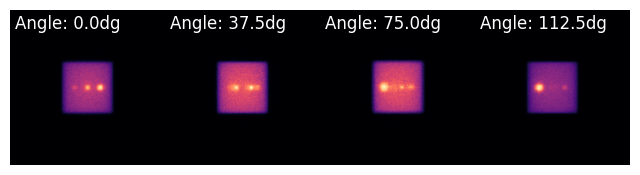

In [7]:
fig, ax = plt.subplots(1,4,figsize=(8,2.4), gridspec_kw={'wspace':0.0})
for i in range(4):
    ax[i].imshow(photopeak[10*i].cpu().T, cmap='magma')
    ax[i].axis('off')
    ax[i].text(0.03, 0.97, f'Angle: {10*proj_meta.angles[i]}dg', ha='left', va='top', color='white', transform=ax[i].transAxes, fontsize=12)

## Conclusión

Este artículo presenta una herramienta de código abierto que es comparable con software de otras compañías para la reconsrucción de imágenes tomográficas. Además, cuenta con una documentación excelente. La librería soporta varios formatos de imágenes y, este caso, se ha utilizado un manejador de ficheros para el formato **SIMIND**. El manejador de ficheros permite acceder tanto a metadatos cómo a las proyecciones del tomógrafo en diferentes ángulos.

Más allá de la implementación mostrada en este trabajo, **PyTomography** también ofrece herramientas para transformar las imágenes y combinar entre varios tipos de tomografías, por ejemplo *computer tomography* (CT) más SPECT. También acepta una gran variedad de formatos incluyendo **DICOM**, **GATE** y **HDF5**.

## Declaración uso IA

Se han utilizado herramientas de IA generativa para formatear la citación a formato APA.